# Bifurcation analysis

In [2]:
from functools import partial 
from collections import defaultdict 
import numpy as np 
import matplotlib.pyplot as plt 
import os
import pathlib
import sys
base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import paths

import scipy.integrate
from mpl_toolkits.mplot3d import axes3d
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import sympy as sp
from sympy import latex
import seaborn as sns
from scipy.optimize import fsolve, root
from IPython.display import display, Math
# %matplotlib inline

from potencial import get_expressions
# plt.rcParams.update({
#     # familia y fuentes
#     'font.family':         'sans-serif',
#     'font.sans-serif':     ['Lato'],
#     'mathtext.fontset':    'custom',
#     'mathtext.rm':         'Lato',
#     'mathtext.it':         'Lato:italic',
#     'mathtext.sf':         'Montserrat',
#     # tamaños (los que acordamos)
#     # 'axes.titlesize':      36,
#     # 'axes.labelsize':      24,
#     # 'xtick.labelsize':     20,
#     # 'ytick.labelsize':     20,
#     # 'legend.fontsize':     20,
#     # pesos para dar “más cuerpo”
#     'font.weight':         'bold',         # peso general
#     'axes.titleweight':    'bold',           # peso del título del eje
#     'axes.labelweight':    'bold',         # peso de las etiquetas de ejes
#     # 'legend.title_fontsize':'24',            # tamaño opcional para título de leyenda
# })
# mpl.font_manager.fontManager.addfont(
#     '/Users/javierrodriguezmartinez/Library/Fonts/Lato-Bold.ttf'
# )
plot_dir = f'{paths.PLOTS}/bifurcations/'

## Importing the functions and parameter definition
We're using for a start:

\begin{align}
c = 1, \quad g = 1, \quad s_0 = 1, \quad I_L = 1, \quad I_C = 1, \quad I_R = 1, \quad I_I = 1/3, \quad s_L = 0, \quad s_C = 0, \quad s_R = 0
\end{align}



In [3]:
import pandas as pd
params = pd.read_csv(f'{paths.PARAMS_DIR}/params_df.csv', index_col=0)
display(params)

,sL,sC,sR,noise_amp,S_amplitude,S_d,U_int_amplitude,U_int_baseline,U_int_onset,U_ext_amplitude,nll
subject,,,,,,,,,,,
A83_julia_ext_julia,0.508430,0.494158,0.498485,0.710225,0.114989,0.643321,0.690380,-0.796679,8.917331e-02,0.001410,5530.439044
A84_julia_ext_julia,0.402548,0.351841,0.424601,0.758967,0.150100,0.554290,0.863990,-0.657471,3.644254e-01,-0.068511,416.026877
A86_julia_ext_julia,0.313336,0.446896,0.422735,1.087690,0.202037,0.197861,1.865245,-1.236308,1.165722e-04,-0.033492,5609.879495
A87_julia_ext_julia,0.546528,0.598203,0.581504,0.642154,0.124134,0.303251,1.081730,-0.939309,5.833452e-02,-0.091281,5543.586787
A89_julia_ext_julia,0.519279,0.519741,0.537677,0.438079,0.074538,0.523835,0.878549,-1.013501,3.199456e-01,0.281368,5672.498620
A92_julia_ext_julia,0.470809,0.515426,0.554880,0.837819,0.140530,0.309033,1.835905,-1.201378,5.316831e-02,-0.044305,6060.541982
A93_julia_ext_julia,0.442970,0.497341,0.477417,0.503003,0.089331,0.312374,1.386028,-1.272345,7.450579e-11,0.297397,4433.376293
A95_julia_ext_julia,0.441566,0.494736,0.473940,0.695791,0.123097,0.986702,1.951871,-0.997691,2.636853e-01,-0.092697,3784.398451
A96_julia_ext_julia,0.618589,0.751825,0.677569,0.695350,0.138952,0.999880,1.962129,-1.619062,8.859597e-05,-0.088202,3902.450112


In [ ]:
X1, X2, I_L, I_C, I_R = sp.symbols('X1 X2 I_L I_C I_R')
values = {
    "tau": 0.1,
    "c": 1,
    "g": 1,
    "s0": 1,
    "IL": 1,
    "IC": 1,
    "IR": 1,
    "I_I": 1/3, # 1/4
    "sL": params.loc['A92_julia_ext_julia', 'sL'],
    "sC": params.loc['A92_julia_ext_julia', 'sC'],
    "sR": params.loc['A92_julia_ext_julia', 'sR'],
}
print
# If you want to substitute I_L, I_C, I_R, set substituted_I = True 
# type = symbolic to get the symbolic expressions
potencial, F1, F2, H= get_expressions(values, type = "symbolic", substituted_I =  False)
_,F1_num, F2_num, H_num = get_expressions(values, type = "numeric", substituted_I =  False)


I = sp.symbols('I')
F1 = F1.subs({I_L: I, I_C: I, I_R: I}).nsimplify()
F2 = F2.subs({I_L: I, I_C: I, I_R: I}).nsimplify()

display(Math(r"F1 = " + latex(F1)))
display(Math(r"F2 = " + latex(F2)))


{'tau': 0.1, 'c': 1, 'g': 1, 's0': 1, 'IL': 1, 'IC': 1, 'IR': 1, 'I_I': 0.3333333333333333, 'sL': 0, 'sC': 0, 'sR': 0}
Piecewise((0, x < 0), (x**2, x <= 1), (2*sqrt(x - 3/4), True))
R: 0.25 R_I: 0.34027777777777735 I0: 0.5902777777777773


<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)


Piecewise((0, x < 0), (x**2, x <= 1), (2*sqrt(x - 3/4), True))
R: 0.25 R_I: 0.34027777777777735 I0: 0.5902777777777773


<lambdifygenerated-16>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Definitions

In [6]:
EQUILIBRIUM_COLOR = {'Stable node':'C0',
                    'Stable':'C0',
                    'Unstable node':'C1', 
                    'Unstable':'C1',
                    'Saddle':'C4',
                    'Stable focus':'C3',
                    'Unstable focus':'C2',
                    'Center':'C5',
                    'Saddle-Node':'C6'}

STABILITY_STYLE = {
    "Stable node": "-",
    "Stable": "-",
    "Stable focus": "-",
    "Unstable node": "--",
    "Unstable focus": "--",
    "Unstable": "--",
    "Saddle": "--",
    "Center": "-.",
    "Saddle-Node": "-."
}

In [7]:
def stability(J):
    det = np.linalg.det(J)
    tr  = np.trace(J)
    eps = 1e-16  # Small value to handle numerical precision issues
    if tr ==0 and det ==0:
        return None
        # return "Center"
    elif det ==0 :
        return "Saddle"
    elif det < 0:
        return "Saddle"
    else:
        base = "Stable" if tr < 0 else "Unstable"
        # return base + (" focus" if (tr**2 - 4*det) < 0 else " node")
        return base
    
def vectorize_constant(f): # Needed to vectorize the function after lambdification
    def fv(x):
        y = f(x)
        if np.isscalar(y) or np.ndim(y)==0:
            return np.full_like(np.array(x, dtype=float), float(y), dtype=float)
        return np.array(y, dtype=float)
    return fv


## Computing the equilibrium points

We first find the equilibrium points for any given $\bar{I}$

In [8]:
I = sp.symbols('I')
F1_s = F1.subs({I_L: I, I_C: I, I_R: I})
F2_s = F2.subs({I_L: I, I_C: I, I_R: I})

soluciones = sp.solve([F1_s, F2_s], [X1, X2], dict=True)
soluciones

[{X1: 0, X2: 0},
 {X1: 0, X2: -sqrt(216*I + 49)/8 - 7/8},
 {X1: 0, X2: sqrt(216*I + 49)/8 - 7/8},
 {X1: -sqrt(-27*I**2/6272 - 9*I*sqrt(9*I**2 + 9702*I + 2401)/6272 + 441*I/64 + 9*sqrt(9*I**2 + 9702*I + 2401)/128 + 441/128),
  X2: 3*I/112 + sqrt(9*I**2 + 9702*I + 2401)/112 + 7/16},
 {X1: sqrt(-27*I**2/6272 - 9*I*sqrt(9*I**2 + 9702*I + 2401)/6272 + 441*I/64 + 9*sqrt(9*I**2 + 9702*I + 2401)/128 + 441/128),
  X2: 3*I/112 + sqrt(9*I**2 + 9702*I + 2401)/112 + 7/16},
 {X1: -sqrt(-27*I**2/6272 + 9*I*sqrt(9*I**2 + 9702*I + 2401)/6272 + 441*I/64 - 9*sqrt(9*I**2 + 9702*I + 2401)/128 + 441/128),
  X2: 3*I/112 - sqrt(9*I**2 + 9702*I + 2401)/112 + 7/16},
 {X1: sqrt(-27*I**2/6272 + 9*I*sqrt(9*I**2 + 9702*I + 2401)/6272 + 441*I/64 - 9*sqrt(9*I**2 + 9702*I + 2401)/128 + 441/128),
  X2: 3*I/112 - sqrt(9*I**2 + 9702*I + 2401)/112 + 7/16}]

In [9]:
def find_equilibria(F1_num, F2_num, I_value,
                    initial_guesses=None,
                    tol=1e-6,
                    grid_limits=(-5,5),
                    grid_points=10):

    def system(vars):
        x1, x2 = vars
        return [
            F1_num(x1, x2, I_value, I_value, I_value),
            F2_num(x1, x2, I_value, I_value, I_value)
        ]

    if initial_guesses is None:
        a, b = grid_limits
        xs = np.linspace(a, b, grid_points)
        ys = np.linspace(a, b, grid_points)
        initial_guesses = [(x, y) for x in xs for y in ys]

    equilibria = []
    for guess in initial_guesses:
        sol = root(system, guess)
        if sol.success and np.allclose(sol.fun, [0, 0], atol=tol):
            x1_sol, x2_sol = sol.x
            if not any(np.hypot(x1_sol - x, x2_sol - y) < tol for x, y in equilibria):
                equilibria.append((x1_sol, x2_sol))

    return equilibria


def jacobian_numeric(F1_num, F2_num, x, y, I_value, h=1e-6):
    # derivades centrals
    F = lambda u, v: np.array([
        F1_num(u, v, I_value, I_value, I_value),
        F2_num(u, v, I_value, I_value, I_value)
    ], float)

    fx1p = F(x + h, y); fx1m = F(x - h, y)
    fx2p = F(x, y + h); fx2m = F(x, y - h)

    dFdx = (fx1p - fx1m) / (2*h)
    dFdy = (fx2p - fx2m) / (2*h)

    J = np.column_stack([dFdx, dFdy])
    return J

def classify_stability(J, eps=1e-9):
    vals = np.linalg.eigvals(J)
    re = np.real(vals)
    if np.any(re > eps) and np.any(re < -eps):
        return "Saddle"
    elif np.all(re < -eps):
        return "Stable"
    elif np.all(re > eps):
        return "Unstable"
    else:
        return "Borderline"


Now we put the solutions on a list and compute the Jacobian to find the stability of the points

In [10]:
vec = sp.Matrix([F1_s, F2_s])
J   = vec.jacobian([X1, X2])

J_funcs = []
for sol in soluciones:
    Jsub = J.subs(sol)
    J_funcs.append([
        sp.lambdify(I, sp.simplify(Jsub[i,j]), 'numpy')
        for i in range(2) for j in range(2)
    ])

f1_list = [sp.lambdify(I, sol[X1], 'numpy') for sol in soluciones]
f2_list = [sp.lambdify(I, sol[X2], 'numpy') for sol in soluciones]


f1_list = [vectorize_constant(f) for f in f1_list]
f2_list = [vectorize_constant(f) for f in f2_list]


## Plots with stability

First saddle appears at I = -0.2475 in branch 6


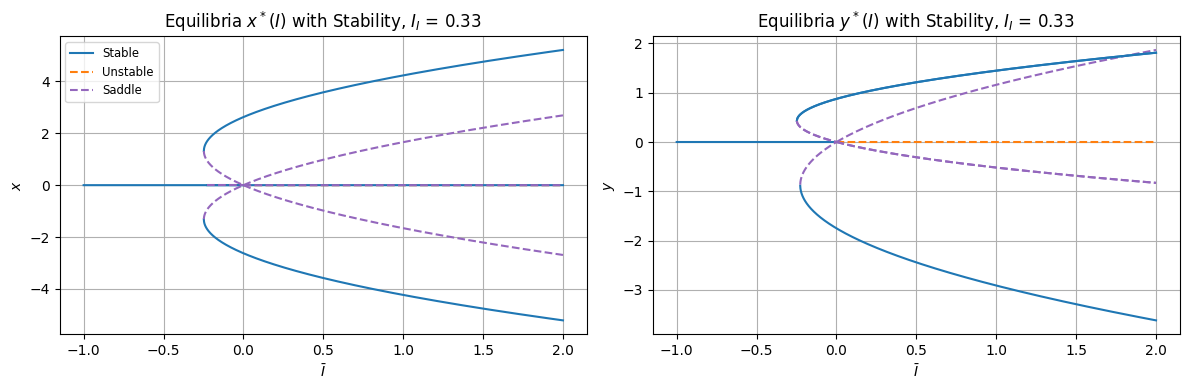

In [11]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

I_vals = np.linspace(-1, 2,10000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

tasks = [
    (ax1, f1_list, '$x$', f'Equilibria $x^*(I)$ with Stability, $I_I$ = {values["I_I"]:.2f}'),
    (ax2, f2_list, '$y$', f'Equilibria $y^*(I)$ with Stability, $I_I$ = {values["I_I"]:.2f}'),
]

for ax, f_list, y_label, title in tasks:
    plotted = set()

    for idx, (f_branch, jf_branch) in enumerate(zip(f_list, J_funcs), 1):
        # 1) evaluamos la rama y su existencia
        y_vals = f_branch(I_vals)
        exists = np.isfinite(y_vals)

        # 2) calculamos estabilidad solo donde existe
        stab = [None] * len(I_vals)
        for k, Iv in enumerate(I_vals):
            if not exists[k]:
                continue
            # reconstruir J
            Jmat = np.array([[jf_branch[0](Iv), jf_branch[1](Iv)],
                             [jf_branch[2](Iv), jf_branch[3](Iv)]], float)
            if not np.isfinite(Jmat).all():
                continue
            # calcular estabilidad
            stab[k] = stability(Jmat)

        # 3) fragmentamos y dibujamos solo los tramos existentes
        start = None
        for k in range(len(I_vals)+1):
            end_of_block = (k == len(I_vals) or stab[k] != stab[start] if start is not None else False)
            if start is None:
                if stab[k] is not None:
                    start = k
            elif end_of_block:
                s = stab[start]
                seg = slice(start, k)
                ax.plot(
                    I_vals[seg], y_vals[seg],
                    linestyle=STABILITY_STYLE[s],
                    color=EQUILIBRIUM_COLOR[s],
                    lw=1.5,
                    label=(s if s not in plotted else '_nolegend_')
                )
                plotted.add(s)
                start = None
                # si el siguiente punto inicia un nuevo tramo
                if k < len(I_vals) and stab[k] is not None:
                    start = k

    ax.set_title(title)
    ax.set_xlabel(r'$\bar{I}$')
    ax.set_ylabel(y_label)
    ax.grid(True)

ax1.legend(loc='best', fontsize='small')
ax2.set_xlabel(r'$\bar{I}$')
# Find and print the first value where a saddle appears
for i, I_val in enumerate(I_vals):
    for f_idx, jf_branch in enumerate(J_funcs):
        try:
            Jmat = np.array([[jf_branch[0](I_val), jf_branch[1](I_val)],
                             [jf_branch[2](I_val), jf_branch[3](I_val)]], float)
            if np.isfinite(Jmat).all() and stability(Jmat) == "Saddle":
                print(f"First saddle appears at I = {I_val:.4f} in branch {f_idx+1}")
                break
        except:
            continue
    else:
        continue
    break
plt.tight_layout()
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.png', dpi=500)
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.svg')
plt.show()

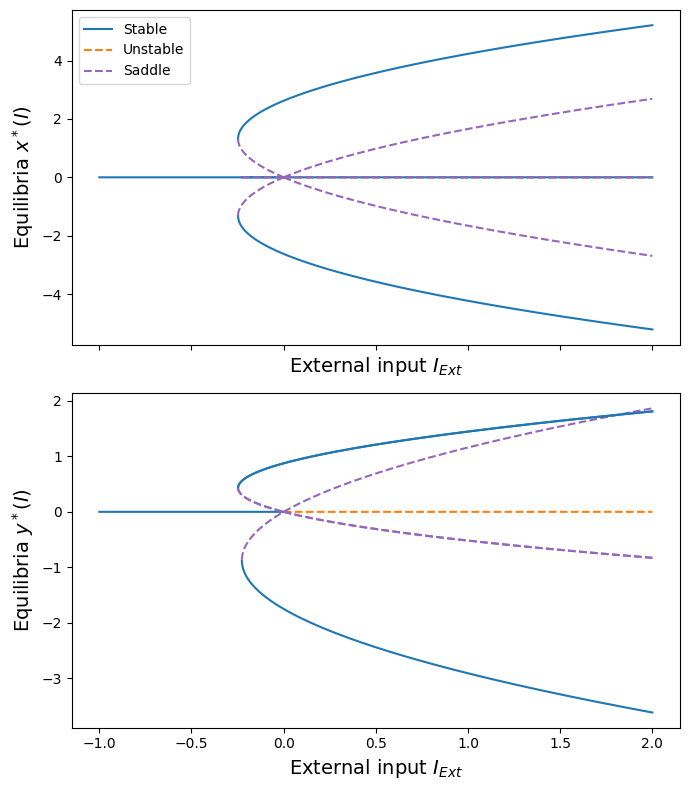

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

tasks = [
    (ax1, f1_list, '$x$', f'Equilibria $x^*(I)$'),
    (ax2, f2_list, '$y$', f'Equilibria $y^*(I)$'),
]

for ax, f_list, y_label, title in tasks:
    ax.set_xlabel(r'External input $I_{Ext}$', fontsize=14)
    ax.set_ylabel(title, fontsize=14)
    # ax.grid(True)

    for idx, (f_br, jf_br) in enumerate(zip(f_list, J_funcs), 1):
        # 1) evaluamos la rama
        y_vals = f_br(I_vals)
        # 2) preparamos un array de etiquetas de estabilidad
        stab = np.full(len(I_vals), None, dtype=object)

        # 3) rellenamos stab sólo donde existe la rama y J es finita
        for k, Iv in enumerate(I_vals):
            if not np.isfinite(y_vals[k]):
                continue
            Jmat = np.array([[jf_br[0](Iv), jf_br[1](Iv)],
                             [jf_br[2](Iv), jf_br[3](Iv)]], float)
            if not np.isfinite(Jmat).all():
                continue
            stab[k] = stability(Jmat)

        plotted = set()
        for s in [st for st in STABILITY_STYLE.keys() if st in stab]:
            # construimos un y_plot que solo tenga y_vals donde stab==s
            y_plot = np.where(stab == s, y_vals, np.nan)
            ax.plot(
                I_vals, y_plot,
                linestyle=STABILITY_STYLE[s],
                color=EQUILIBRIUM_COLOR[s],
                lw=1.5,
                label=(s if s not in plotted else '_nolegend_')
            )
            plotted.add(s)
            
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='best', fontsize='medium')
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.png', dpi=500)
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.svg')
# ax1.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()


### Numerical

First saddle appears at I = -0.2437


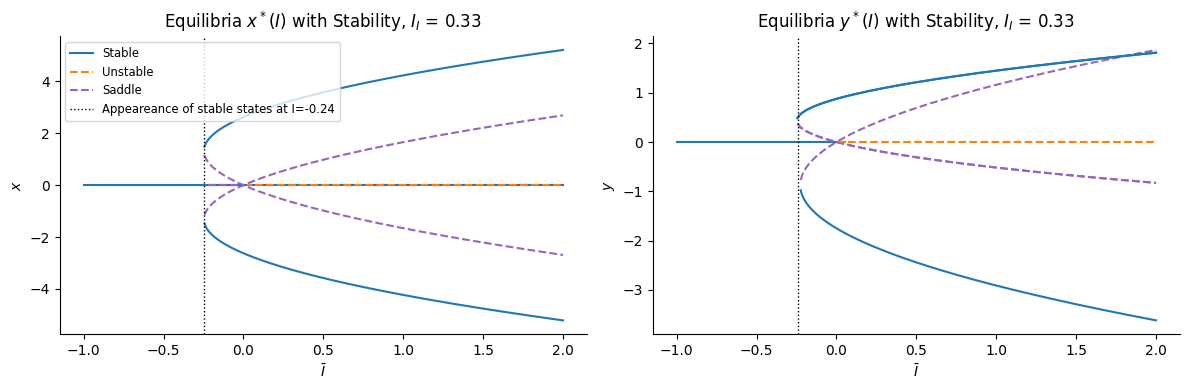

In [13]:
I_vals = np.linspace(-1, 2, 600)

max_jump = 0.25
tol_branch_merge = 1e-3

branches = []

def attach_to_branches(solutions, I_val, stabs, branches, max_jump):
    used = set()
    for br in branches:
        x_last = br['x'][-1]
        y_last = br['y'][-1]

        best_j = -1
        best_d = np.inf
        for j, (xy) in enumerate(solutions):
            if j in used:
                continue
            d = np.hypot(xy[0] - x_last, xy[1] - y_last)
            if d < best_d:
                best_d = d
                best_j = j
        if best_j >= 0 and best_d <= max_jump:
            used.add(best_j)
            br['I'].append(I_val)
            br['x'].append(solutions[best_j][0])
            br['y'].append(solutions[best_j][1])
            br['stab'].append(stabs[best_j])

    for j, (xy) in enumerate(solutions):
        if j not in used:
            branches.append({'I':[I_val], 'x':[xy[0]], 'y': [xy[1]], 'stab':['Saddle'] if stabs is None else [stabs[j]]})

first_saddle_I = None

for I_val in I_vals:
    sols = find_equilibria(F1_num, F2_num, I_val, grid_limits=(-5,5), grid_points=12)
    if not sols:
        continue

    stabs = []
    for (x, y) in sols:
        J = jacobian_numeric(F1_num, F2_num, x, y, I_val)
        s = classify_stability(J)
        stabs.append(s)
        if first_saddle_I is None and s == "Saddle":
            first_saddle_I = I_val

    if not branches:
        for (x, y), s in zip(sols, stabs):
            branches.append({'I':[I_val], 'x':[x], 'y':[y], 'stab':[s]})
    else:
        attach_to_branches(sols, I_val, stabs, branches, max_jump=max_jump)


def plot_branches(ax, coord_key, ylabel, title):
    plotted_labels = set()
    for br in branches:
        I_arr = np.array(br['I'])
        Y_arr = np.array(br[coord_key])
        S_arr = np.array(br['stab'], dtype=object)
        if len(I_arr) < 2:
            continue

        start = 0
        for k in range(1, len(I_arr)+1):
            change = (k == len(I_arr)) or (S_arr[k] != S_arr[k-1]) or (abs(I_arr[k] - I_arr[k-1]) > (I_vals[1]-I_vals[0])*2.1)
            if change:
                s = S_arr[k-1]
                lab = s if s not in plotted_labels else '_nolegend_'
                ax.plot(I_arr[start:k], Y_arr[start:k], linestyle=STABILITY_STYLE.get(s, '-'), color=EQUILIBRIUM_COLOR.get(s, 'black'), lw=1.5, label=lab)
                plotted_labels.add(s)
                start = k

    ax.set_title(title)
    ax.set_xlabel(r'$\bar{I}$')
    ax.set_ylabel(ylabel)
    ax.grid(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

plot_branches(ax1, 'x', r'$x$', f'Equilibria $x^*(I)$ with Stability, $I_I$ = {values["I_I"]:.2f}')
plot_branches(ax2, 'y', r'$y$', f'Equilibria $y^*(I)$ with Stability, $I_I$ = {values["I_I"]:.2f}')

if first_saddle_I is not None:
    print(f"First saddle appears at I = {first_saddle_I:.4f}")
    ax1.axvline(first_saddle_I, color='k', linestyle=':', lw=1, label=f'Appeareance of stable states at I={first_saddle_I:.2f}')
    ax2.axvline(first_saddle_I, color='k', linestyle=':', lw=1, label=f'Appeareance of stable states at I={first_saddle_I:.2f}')
else:
    print("No saddle detected on the scanned I-range.")

ax1.legend(loc='best', fontsize='small')
ax2.set_xlabel(r'$\bar{I}$')


plt.tight_layout()
ax1.grid(False)
ax2.grid(False)
sns.despine()
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.png', dpi=500)
plt.savefig(f'{plot_dir}equilibria_stability_I_I_{values["I_I"]:.2f}.svg')
plt.show()

## Eigenvalue analysis

Rama 1: X1*(-2) = 0.0000, X2*(-2) = 0.0000
Rama 2: X1*(-2) = 0.0000, X2*(-2) = 0.0000
Rama 3: X1*(-2) = 6.0000, X2*(-2) = 6.0000
Rama 4: X1*(-2) = -6.0000, X2*(-2) = -6.0000


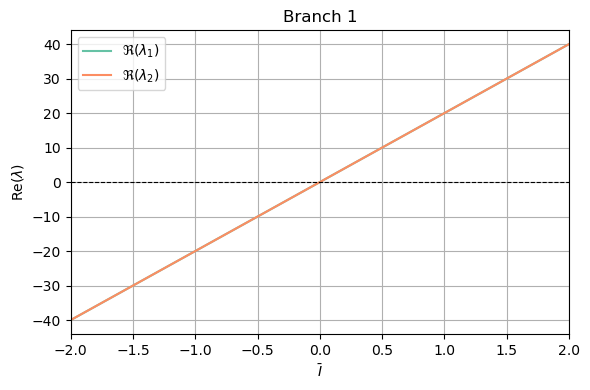

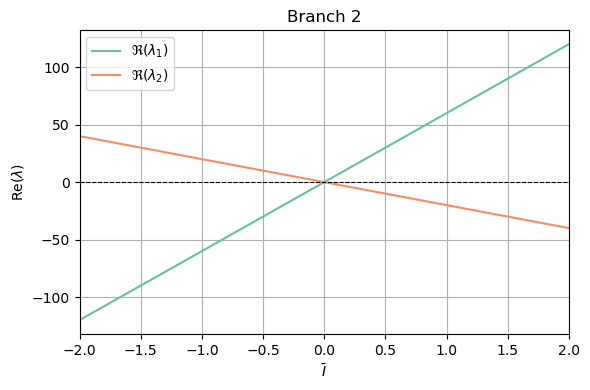

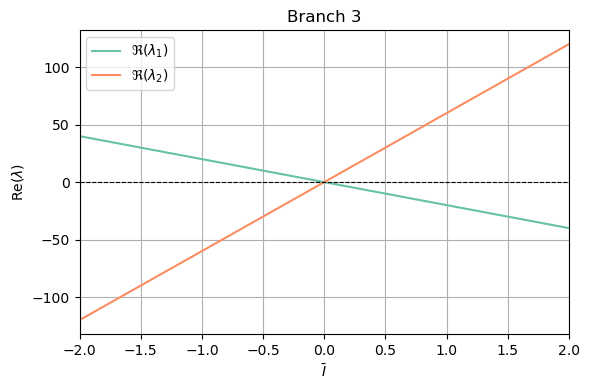

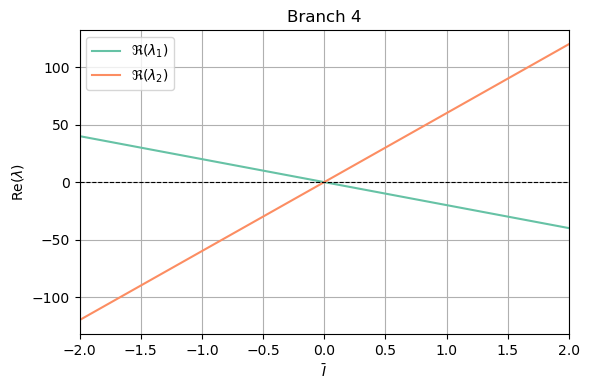

In [95]:
I_vals = np.linspace(-2, 2, 10000)
cmap = plt.get_cmap('Set2')
eqs_at_ref = [f(-2) for f in f1_list]
eqs_at_ref2 = [f(-2) for f in f2_list]
for idx, val in enumerate(eqs_at_ref, start=1):
    print(f"Rama {idx}: X1*({-2}) = {val:.4f}, X2*({-2}) = {eqs_at_ref[idx-1]:.4f}")

def plot_segments(ax, x, y, **plot_kwargs):
    finite = np.isfinite(y)
    idx = np.where(np.diff(finite.astype(int)) != 0)[0] + 1
    bounds = np.concatenate([[0], idx, [len(y)]])
    for start, end in zip(bounds[:-1], bounds[1:]):
        if finite[start]:
            ax.plot(x[start:end], y[start:end], **plot_kwargs)

for branch_idx, jf in enumerate(J_funcs, start=1):
    re1, re2 = [], []
    for Iv in I_vals:
        J = np.array([[jf[0](Iv), jf[1](Iv)],
                      [jf[2](Iv), jf[3](Iv)]], float)
        if not np.isfinite(J).all():
            re1.append(np.nan); re2.append(np.nan)
            continue
        try:
            eigs = np.linalg.eigvals(J)
            re1.append(np.real(eigs[0]))
            re2.append(np.real(eigs[1]))
        except np.linalg.LinAlgError:
            re1.append(np.nan); re2.append(np.nan)

    color1, color2 = cmap.colors[0], cmap.colors[1]

    fig, ax = plt.subplots(figsize=(6,4))
    plot_segments(ax, I_vals, re1, label=r'$\Re(\lambda_1)$', color=color1)
    plot_segments(ax, I_vals, re2, label=r'$\Re(\lambda_2)$', color=color2)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlim(I_vals[0], I_vals[-1])
    ax.set_xlabel(r'$\bar I$')
    ax.set_ylabel(r'Re($\lambda$)')
    ax.set_title(f'Branch {branch_idx}')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    # plt.savefig(f'{plot_dir}eigenvalues_branch_{branch_idx}.png', dpi=500)
    plt.show()

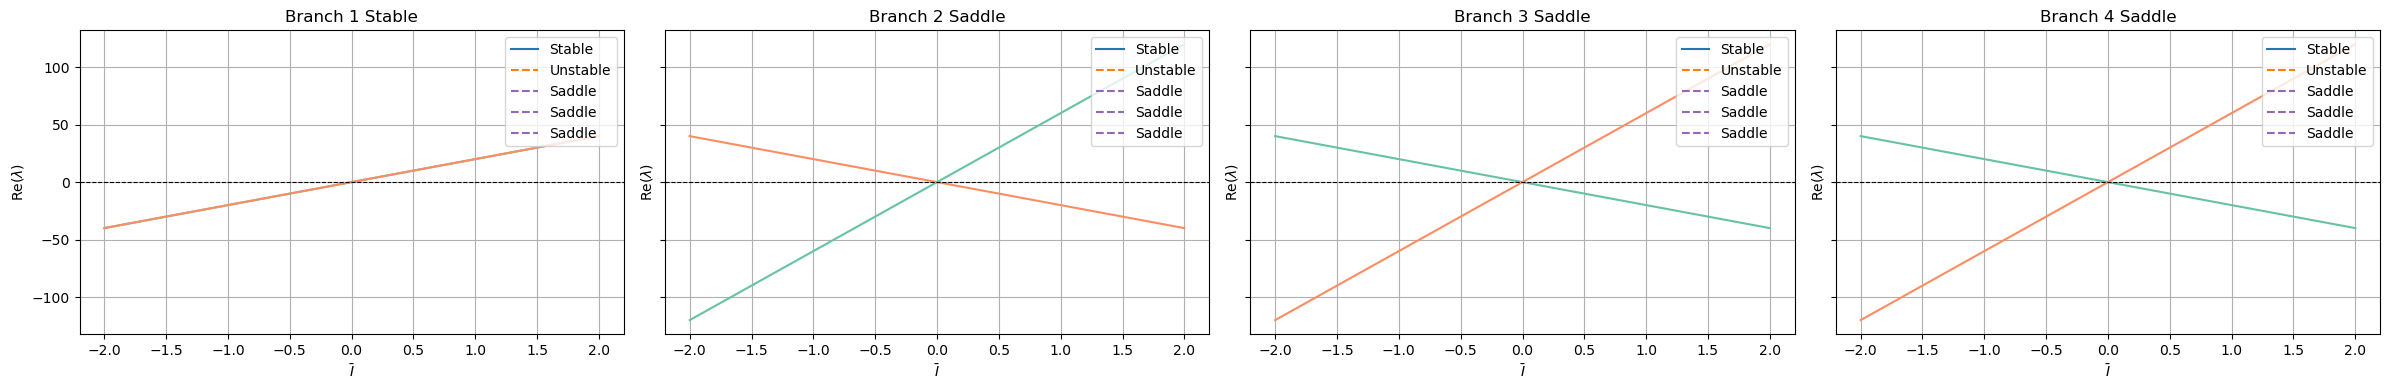

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Asumo que I_vals, J_funcs y plot_segments ya están definidos
# I_vals = np.linspace(-2, 2, 10000)
# J_funcs = [...]  
cmap = plt.get_cmap('Set2')

n_branches = len(J_funcs)
n_cols     = 4
n_rows     = math.ceil(n_branches / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for idx, (ax, jf) in enumerate(zip(axes, J_funcs), start=1):
    re1, re2 = [], []
    for Iv in I_vals:
        J = np.array([[jf[0](Iv), jf[1](Iv)],
                      [jf[2](Iv), jf[3](Iv)]], float)
        if not np.isfinite(J).all():
            re1.append(np.nan); re2.append(np.nan)
            continue
        try:
            eigs = np.linalg.eigvals(J)
            re1.append(np.real(eigs[0]))
            re2.append(np.real(eigs[1]))
        except np.linalg.LinAlgError:
            re1.append(np.nan); re2.append(np.nan)

    color1, color2 = cmap.colors[0], cmap.colors[1]

    plot_segments(ax, I_vals, np.array(re1),
                  label=r'$\Re(\lambda_1)$', color=color1)
    plot_segments(ax, I_vals, np.array(re2),
                  label=r'$\Re(\lambda_2)$', color=color2)

    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(f'Branch {idx} {"Stable" if idx == 1 else "Saddle"}')
    ax.grid(True)
    ax.legend(handles, labels, loc='upper right', ncol=1, fontsize='medium')

# Apaga ejes sobrantes si n_branches < n_rows*n_cols
for ax in axes[n_branches:]:
    ax.axis('off')

# Leyenda común (opcional)
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=2, fontsize='medium')

for ax in axes:
    ax.set_xlabel(r'$\bar I$')
    ax.set_ylabel(r'Re($\lambda$)')

plt.tight_layout()
plt.savefig(f'{plot_dir}I_I_{values["I_I"]:.2f}eigenvalues_branches.png', dpi=500)
plt.show()


IndexError: list index out of range

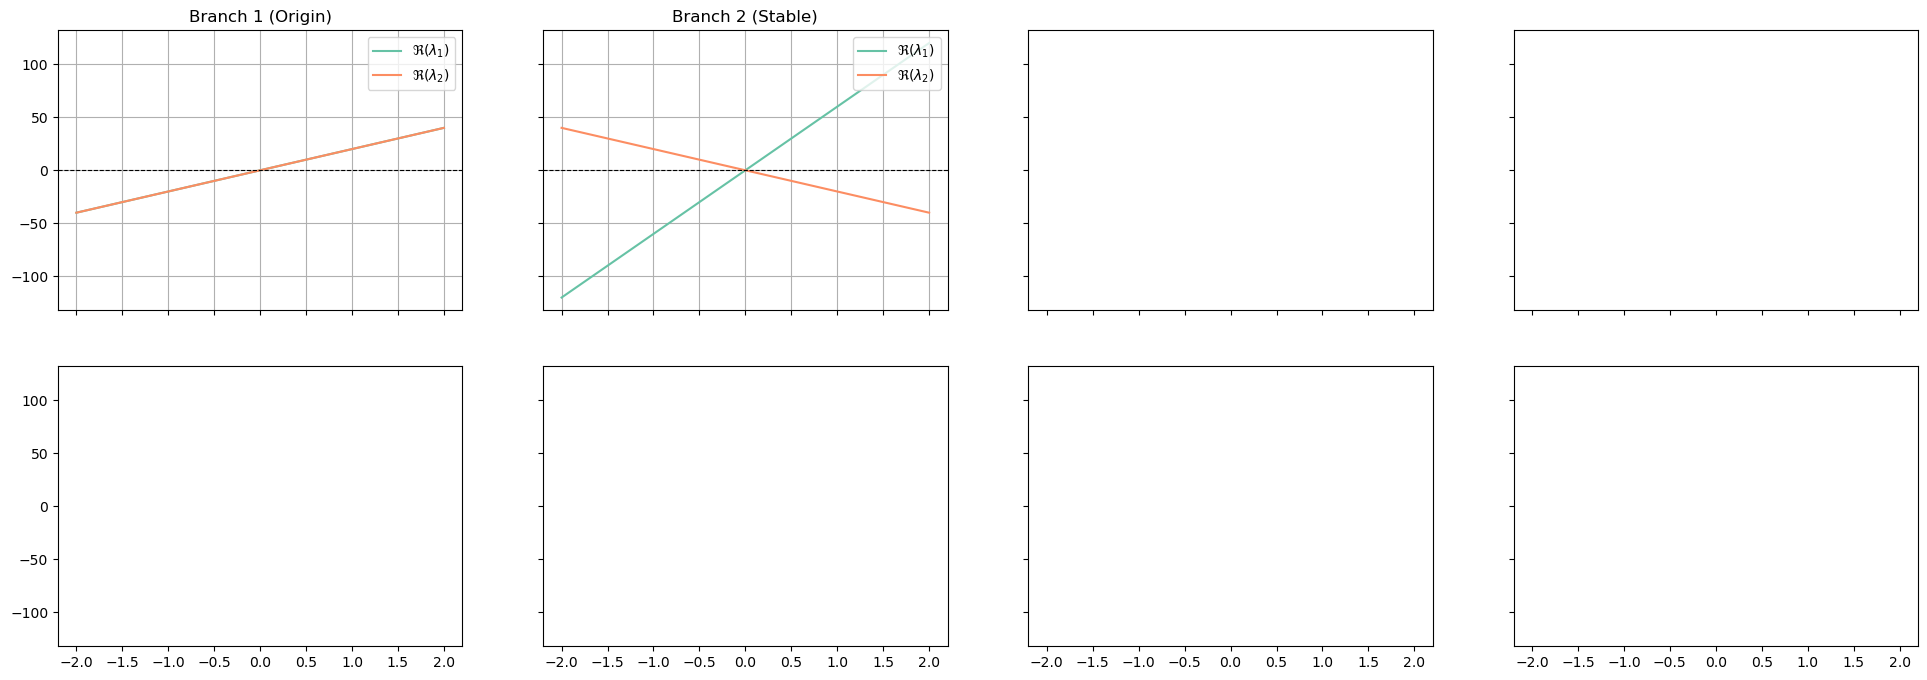

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Assume I_vals, J_funcs, plot_segments, plot_dir, values are predefined
# I_vals = np.linspace(-2, 2, 10000)
# J_funcs = [...]  # length 7
# plot_segments(ax, x, y, label, color) defined elsewhere
# values = {"I_I": 0.25}
# plot_dir = "plots/"

cmap = plt.get_cmap('Set2')

# Explicit branch ordering: 1=origin, 2-4=stable, 5-7=saddle
branch_order = [0, 1, 4, 3, 2, 5, 6]  # indices in J_funcs
branch_labels = {
    0: 'Origin',
    1: 'Stable',
    2: 'Saddle',
    3: 'Stable',
    4: 'Stable',
    5: 'Saddle',
    6: 'Saddle'
}

n_branches = len(branch_order)
n_cols = 4
n_rows = math.ceil(n_branches / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for plot_idx, orig_idx in enumerate(branch_order):
    jf = J_funcs[orig_idx]
    ax = axes[plot_idx]
    re1, re2 = [], []
    for Iv in I_vals:
        J = np.array([[jf[0](Iv), jf[1](Iv)],
                      [jf[2](Iv), jf[3](Iv)]], float)
        if not np.isfinite(J).all():
            re1.append(np.nan)
            re2.append(np.nan)
            continue
        eigs = np.linalg.eigvals(J)
        re1.append(np.real(eigs[0]))
        re2.append(np.real(eigs[1]))

    color1, color2 = cmap.colors[0], cmap.colors[1]

    plot_segments(ax, I_vals, np.array(re1),
                  label=r'$\Re(\lambda_1)$', color=color1)
    plot_segments(ax, I_vals, np.array(re2),
                  label=r'$\Re(\lambda_2)$', color=color2)

    ax.axhline(0, color='k', lw=0.8, ls='--')
    class_name = branch_labels[orig_idx]
    ax.set_title(f'Branch {orig_idx+1} ({class_name})')
    ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper right', fontsize='medium')

# Turn off unused axes
for ax in axes[n_branches:]:
    ax.axis('off')

# Axis labels
for ax in axes:
    ax.set_xlabel(r'$\bar I$')
    ax.set_ylabel(r'Re($\lambda$)')

plt.tight_layout()
plt.savefig(f'{plot_dir}I_I_{values["I_I"]:.2f}_eigenvalues_branches.png', dpi=500)
plt.show()
